In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import os
from datetime import datetime
from scipy.stats import poisson
from scipy.signal import fftconvolve
import time
from scipy.signal import find_peaks 
import re
import math



In [2]:
data_path_mu_4 = '/Volumes/RFsoc/ZCU208B/Data/20260310/Matterhorn/gN2a8-10/Pulsed_Laser_Source/1636/mu4/'
data_path_mu_3 = '/Volumes/RFsoc/ZCU208B/Data/20260310/Matterhorn/gN2a8-10/Pulsed_Laser_Source/1636/mu3/'
data_path_mu_2 = '/Volumes/RFsoc/ZCU208B/Data/20260312/Matterhorn/gN2a8-10/Pulsed_Laser_Source/1014/mu_2/'
data_path_mu_1 = '/Volumes/RFsoc/ZCU208B/Data/20260311/Matterhorn/gN2a8-10/Pulsed_Laser_Source/1600/mu_1/'
data_path_mu_05 = '/Volumes/RFsoc/ZCU208B/Data/20260311/Matterhorn/gN2a8-10/Pulsed_Laser_Source/1600/mu_05/'

In [3]:
measured_mu_4_path = '/Volumes/gap-qtech/Group/Projects/Detectors/SNSPD/Measurements/PNR/gN2a/08-10/-1180uA/20260310-RFSOC_statistics-08-10_T1k=0.93_14-31_R=6.4MHz_mu=4/20260310-RFSOC_statistics-08-10_T1k=0.93_14-31_R=6.4MHz_mu=4_calibration.txt'
measured_mu_3_path = '/Volumes/gap-qtech/Group/Projects/Detectors/SNSPD/Measurements/PNR/gN2a/08-10/-1180uA/20260310-RFSOC_statistics-08-10_T1k=0.93_15-48_R=6.4MHz_mu=3/20260310-RFSOC_statistics-08-10_T1k=0.93_15-48_R=6.4MHz_mu=3_calibration.txt'
measured_mu_2_path = '/Volumes/gap-qtech/Group/Projects/Detectors/SNSPD/Measurements/PNR/gN2a/08-10/-1180uA/20260312-RFSOC_statistics-08-10_T1k=0.93_09-37_R=6.4MHz_mu=2/20260312-RFSOC_statistics-08-10_T1k=0.93_09-37_R=6.4MHz_mu=2_calibration.txt'
measured_mu_1_path = '/Volumes/gap-qtech/Group/Projects/Detectors/SNSPD/Measurements/PNR/gN2a/08-10/-1180uA/20260311-RFSOC_statistics-08-10_T1k=0.93_13-54_R=6.4MHz_mu=1/20260311-RFSOC_statistics-08-10_T1k=0.93_13-54_R=6.4MHz_mu=1_calibration.txt'
measured_mu_05_path = '/Volumes/gap-qtech/Group/Projects/Detectors/SNSPD/Measurements/PNR/gN2a/08-10/-1180uA/20260311-RFSOC_statistics-08-10_T1k=0.93_15-10_R=6.4MHz_mu=0.5/20260311-RFSOC_statistics-08-10_T1k=0.93_15-10_R=6.4MHz_mu=0.5_calibration.txt'

In [4]:
date = str(datetime.now())[0:10]
day = date[0:4]+date[5:7]+date[8:10]
s_live = str(datetime.now())
s_live[11:13] + s_live[14:16]


'1031'

In [5]:
device_name = "Matterhorn"
detector_name = "gN2a8-10"
laser_name = "Pulsed_Laser_Source"
mean_photon_number = 2
measurement_type = "Signal_analysis"



# plt.savefig(os.path.join(data_path, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "measurement.png"))

save_dir = os.path.join("/Volumes", "RFsoc", "ZCU208B", "Data", day, device_name, detector_name, laser_name, f"{s_live[11:13]}{s_live[14:16]}", measurement_type)
os.makedirs(save_dir, exist_ok=True)



#plt.savefig(os.path.join("Volumes", "RFsoc", "ZCU208B", "Data", day, device_name, detector_name, laser_name, f"{s_live[11:13]}{s_live[14:16]}", measurement_type, "measurement.png"), dpi=500)

In [6]:
def extract_mu_from_txt(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read()

    match = re.search(r"mu\s*=\s*([0-9.eE+-]+)", text)
    if match is None:
        raise ValueError("Could not find mu value in file.")

    return float(match.group(1))

In [7]:
measured_mu_4 = extract_mu_from_txt(measured_mu_4_path)
measured_mu_3 = extract_mu_from_txt(measured_mu_3_path)
measured_mu_2 = extract_mu_from_txt(measured_mu_2_path)
measured_mu_1 = extract_mu_from_txt(measured_mu_1_path)
measured_mu_05 = extract_mu_from_txt(measured_mu_05_path)


In [8]:
data_mu_3 = np.loadtxt(os.path.join(data_path_mu_3, "continuous_waveforms_1M.csv"), delimiter=",")
data_mu_2 = np.loadtxt(os.path.join(data_path_mu_2, "continuous_waveforms_1M.csv"), delimiter=",")
data_mu_1 = np.loadtxt(os.path.join(data_path_mu_1, "continuous_waveforms_1M.csv"), delimiter=",")
data_mu_05 = np.loadtxt(os.path.join(data_path_mu_05, "continuous_waveforms_1M.csv"), delimiter=",")

threshold_counts_measurment_mu_3 = np.loadtxt(os.path.join(data_path_mu_3, "thresholds_counts.csv"), delimiter=",", skiprows=1)
thresholds_counts_measurement_mu_2 = np.loadtxt(os.path.join(data_path_mu_2, "thresholds_counts.csv"), delimiter=",", skiprows=1)
thresholds_counts_measurement_mu_1 = np.loadtxt(os.path.join(data_path_mu_1, "thresholds_counts.csv"), delimiter=",", skiprows=1)
thresholds_counts_measurement_mu_05 = np.loadtxt(os.path.join(data_path_mu_05, "thresholds_counts.csv"), delimiter=",", skiprows=1)


dps_rate_measurement_mu_3 = np.loadtxt(os.path.join(data_path_mu_3, "dps_corrected_thresholds.csv"), delimiter=",", skiprows=1)
dps_rate_measurement_mu_2 = np.loadtxt(os.path.join(data_path_mu_2, "dps_corrected_thresholds.csv"), delimiter=",", skiprows=1)
dps_rate_measurement_mu_1 = np.loadtxt(os.path.join(data_path_mu_1, "dps_corrected_thresholds.csv"), delimiter=",", skiprows=1)
dps_rate_measurement_mu_05 = np.loadtxt(os.path.join(data_path_mu_05, "dps_corrected_thresholds.csv"), delimiter=",", skiprows=1)


In [10]:
print(threshold_counts_measurment_mu_3[1][0])
print(dps_rate_measurement_mu_3[:,1])


34100.0
[8260644. 5102512. 2372933.  854125.  244334.   11233.   10872.       0.
       0.       0.       0.       0.       0.       0.       0.       0.
       0.       0.       0.       0.]


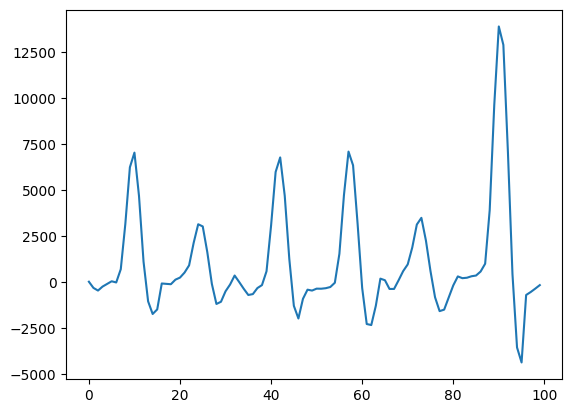

In [11]:
plt.plot(data_mu_3[0:100])

In [12]:
R_trigger_mu_3 = dps_rate_measurement_mu_3[0][2]
R_trigger_mu_2 = dps_rate_measurement_mu_2[0][2]
R_trigger_mu_1 = dps_rate_measurement_mu_1[0][2]
R_trigger_mu_05 = dps_rate_measurement_mu_05[0][2]
print(R_trigger_mu_3)
print(R_trigger_mu_2)
print(R_trigger_mu_1)
print(R_trigger_mu_05)

10000013.0
10000013.0
10000013.0
10000013.0


In [13]:
R_detected_mu_3 = dps_rate_measurement_mu_3[0][1]
R_detected_mu_2 = dps_rate_measurement_mu_2[0][1]
R_detected_mu_1 = dps_rate_measurement_mu_1[0][1]
R_detected_mu_05 = dps_rate_measurement_mu_05[0][1]
print(R_detected_mu_3)
print(R_detected_mu_2)
print(R_detected_mu_1)
print(R_detected_mu_05)

8260644.0
6539964.0
4196845.0
2399870.0


In [14]:
N_detected_mu_3 = R_detected_mu_3 / R_trigger_mu_3
N_detected_mu_2 = R_detected_mu_2 / R_trigger_mu_2
N_detected_mu_1 = R_detected_mu_1 / R_trigger_mu_1
N_detected_mu_05 = R_detected_mu_05 / R_trigger_mu_05
print(N_detected_mu_3)
print(N_detected_mu_2)
print(N_detected_mu_1)
print(N_detected_mu_05)

0.8260633261176761
0.6539955498057852
0.41968395441085926
0.23998668801730558


In [15]:


def dps_to_individual_counts(dps_array, total_triggers=None, use_trigger_column=True):
    """
    Convert a dps_rate_measurement array of shape (N, 3):
        [threshold, cumulative_counts, trigger_counts]
    into individual photon counts.

    Parameters
    ----------
    dps_array : np.ndarray
        Array with columns:
        0 -> threshold
        1 -> cumulative counts (>=1, >=2, >=3, ...)
        2 -> trigger counts

    total_triggers : int or float, optional
        If provided, use this value directly.

    use_trigger_column : bool
        If True and total_triggers is None, use the first nonzero value
        found in column 2 as total_triggers.

    Returns
    -------
    thresholds : np.ndarray
        Thresholds corresponding to cumulative bins kept.

    cumulative_counts : np.ndarray
        Cleaned cumulative counts.

    individual_counts : np.ndarray
        Individual counts [0,1,2,...,last_tail] if total_triggers is known,
        otherwise [1,2,...,last_tail].
    """
    dps_array = np.asarray(dps_array)

    # Keep only rows with nonzero cumulative counts
    mask = dps_array[:, 1] > 0
    cleaned = dps_array[mask]

    thresholds = cleaned[:, 0]
    cumulative_counts = cleaned[:, 1]

    # Determine total triggers
    if total_triggers is None and use_trigger_column:
        trigger_vals = cleaned[:, 2][cleaned[:, 2] > 0]
        if len(trigger_vals) > 0:
            total_triggers = trigger_vals[0]

    # Convert cumulative -> individual
    individual_counts = cumulative_counts[:-1] - cumulative_counts[1:]
    individual_counts = np.append(individual_counts, cumulative_counts[-1])

    if total_triggers is not None:
        count_0 = total_triggers - cumulative_counts[0]
        individual_counts = np.insert(individual_counts, 0, count_0)

    return thresholds, cumulative_counts, individual_counts

In [16]:
thresholds_mu_3, cumulative_counts_mu_3, individual_counts_mu_3 = dps_to_individual_counts(dps_rate_measurement_mu_3)

print("Mu 3:")
print("thresholds:", thresholds_mu_3)
print("cumulative counts:", cumulative_counts_mu_3)
print("individual counts:", individual_counts_mu_3)
print("\n")

thresholds_mu_2, cumulative_counts_mu_2, individual_counts_mu_2 = dps_to_individual_counts(dps_rate_measurement_mu_2)

print("Mu 2:")
print("thresholds:", thresholds_mu_2)
print("cumulative counts:", cumulative_counts_mu_2)
print("individual counts:", individual_counts_mu_2)
print("\n")

thresholds_mu_1, cumulative_counts_mu_1, individual_counts_mu_1 = dps_to_individual_counts(dps_rate_measurement_mu_1)

print("Mu 1:")
print("thresholds:", thresholds_mu_1)
print("cumulative counts:", cumulative_counts_mu_1)
print("individual counts:", individual_counts_mu_1)
print("\n")

thresholds_mu_05, cumulative_counts_mu_05, individual_counts_mu_05 = dps_to_individual_counts(dps_rate_measurement_mu_05)

print("Mu 0.5:")
print("thresholds:", thresholds_mu_05)
print("cumulative counts:", cumulative_counts_mu_05)
print("individual counts:", individual_counts_mu_05)
print("\n")


Mu 3:
thresholds: [34800. 37900. 41400. 45000. 48700. 55700. 56300.]
cumulative counts: [8260644. 5102512. 2372933.  854125.  244334.   11233.   10872.]
individual counts: [1.739369e+06 3.158132e+06 2.729579e+06 1.518808e+06 6.097910e+05
 2.331010e+05 3.610000e+02 1.087200e+04]


Mu 2:
thresholds: [34850. 38000. 41350. 44800.]
cumulative counts: [6539964. 2798985.  844337.  191878.]
individual counts: [3460049. 3740979. 1954648.  652459.  191878.]


Mu 1:
thresholds: [34850. 37900. 41250. 44800.]
cumulative counts: [4196845. 1007616.  163043.   19572.]
individual counts: [5803168. 3189229.  844573.  143471.   19572.]


Mu 0.5:
thresholds: [34850. 38100. 41250.]
cumulative counts: [2399870.  304559.   25360.]
individual counts: [7600143. 2095311.  279199.   25360.]




individual_counts_mu_X are the different rates of photon numbers, R_photon=1, R_photon=2, R_photon=0...



In [17]:
print(individual_counts_mu_05)
print(np.sum(individual_counts_mu_05))

[7600143. 2095311.  279199.   25360.]
10000013.0


In [18]:
def threshold_to_signed(x):
    return int(x) ^ 0x8000

In [18]:
thresholds_mu_3[1]
threshold_to_signed(np.asarray(thresholds_mu_3[1]))

5132

780

In [24]:
def classify_chunks_by_thresholds(data, thresholds, chunk_size=16):
    """
    Classify chunks of data using the chunk maximum and threshold intervals.

    Parameters
    ----------
    data : array-like
        1D array of samples.
    thresholds : array-like
        Ordered threshold values. Example:
        [34800, 37900, 41400, 45000]
    chunk_size : int
        Number of samples per chunk.

    Returns
    -------
    photon_numbers : list
        Photon classification for each chunk:
        0 if max < thresholds[0]
        1 if thresholds[0] <= max < thresholds[1]
        2 if thresholds[1] <= max < thresholds[2]
        ...
        len(thresholds) if max >= thresholds[-1]
    """
    signed_thresholds = np.array([threshold_to_signed(t) for t in thresholds])
    
    photon_numbers = []

    for i in range(0, len(data), chunk_size):
        chunk = data[i:i + chunk_size]

        if len(chunk) == 0:
            continue

        m = np.max(chunk)

        photon_bin = np.searchsorted(signed_thresholds, m, side='right')
        photon_numbers.append(photon_bin)

    return photon_numbers


def classify(data, chunk_size=16):
    waveforms = []
    max = []
    
    for i in range(0, len(data), chunk_size):
        chunk = data[i:i + chunk_size]

        waveforms.append(chunk)
        max.append(np.max(chunk))
    return waveforms, max


def classify_photon_number_max_ampltitude(data, thresholds):
    photon_number = []
    for waveform in data:
        m = np.max(waveform)
        photon_bin = np.searchsorted(thresholds, m, side='right')
        photon_number.append(photon_bin)
    return photon_number
    


def count_photon_numbers(photon_number_distribution):
    photon_number_distribution = np.asarray(photon_number_distribution, dtype=int)
    return np.bincount(photon_number_distribution)




def zero_integer_bins(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]                 # drop NaNs/inf
    lo = int(np.floor(x.min()))
    hi = int(np.ceil(x.max()))
    edges = np.arange(lo - 0.5, hi + 1.5, 1.0)  # half-step edges
    counts, _ = np.histogram(x, bins=edges)
    ints = np.arange(lo, hi + 1)
    zeros = ints[counts == 0]
    # collapse consecutive zero bins into ranges
    ranges = []
    if zeros.size:
        s = e = zeros[0]
        for z in zeros[1:]:
            if z == e + 1:
                e = z
            else:
                ranges.append((s, e))
                s = e = z
        ranges.append((s, e))
    return ints, counts, zeros, ranges

In [25]:
seperated_waveforms_mu_3, max_amplitude_mu_3 = classify(data_mu_3)
seperated_waveforms_mu_2, max_amplitude_mu_2 = classify(data_mu_2)
seperated_waveforms_mu_1, max_amplitude_mu_1 = classify(data_mu_1)
seperated_waveforms_mu_05, max_amplitude_mu_05 = classify(data_mu_05)

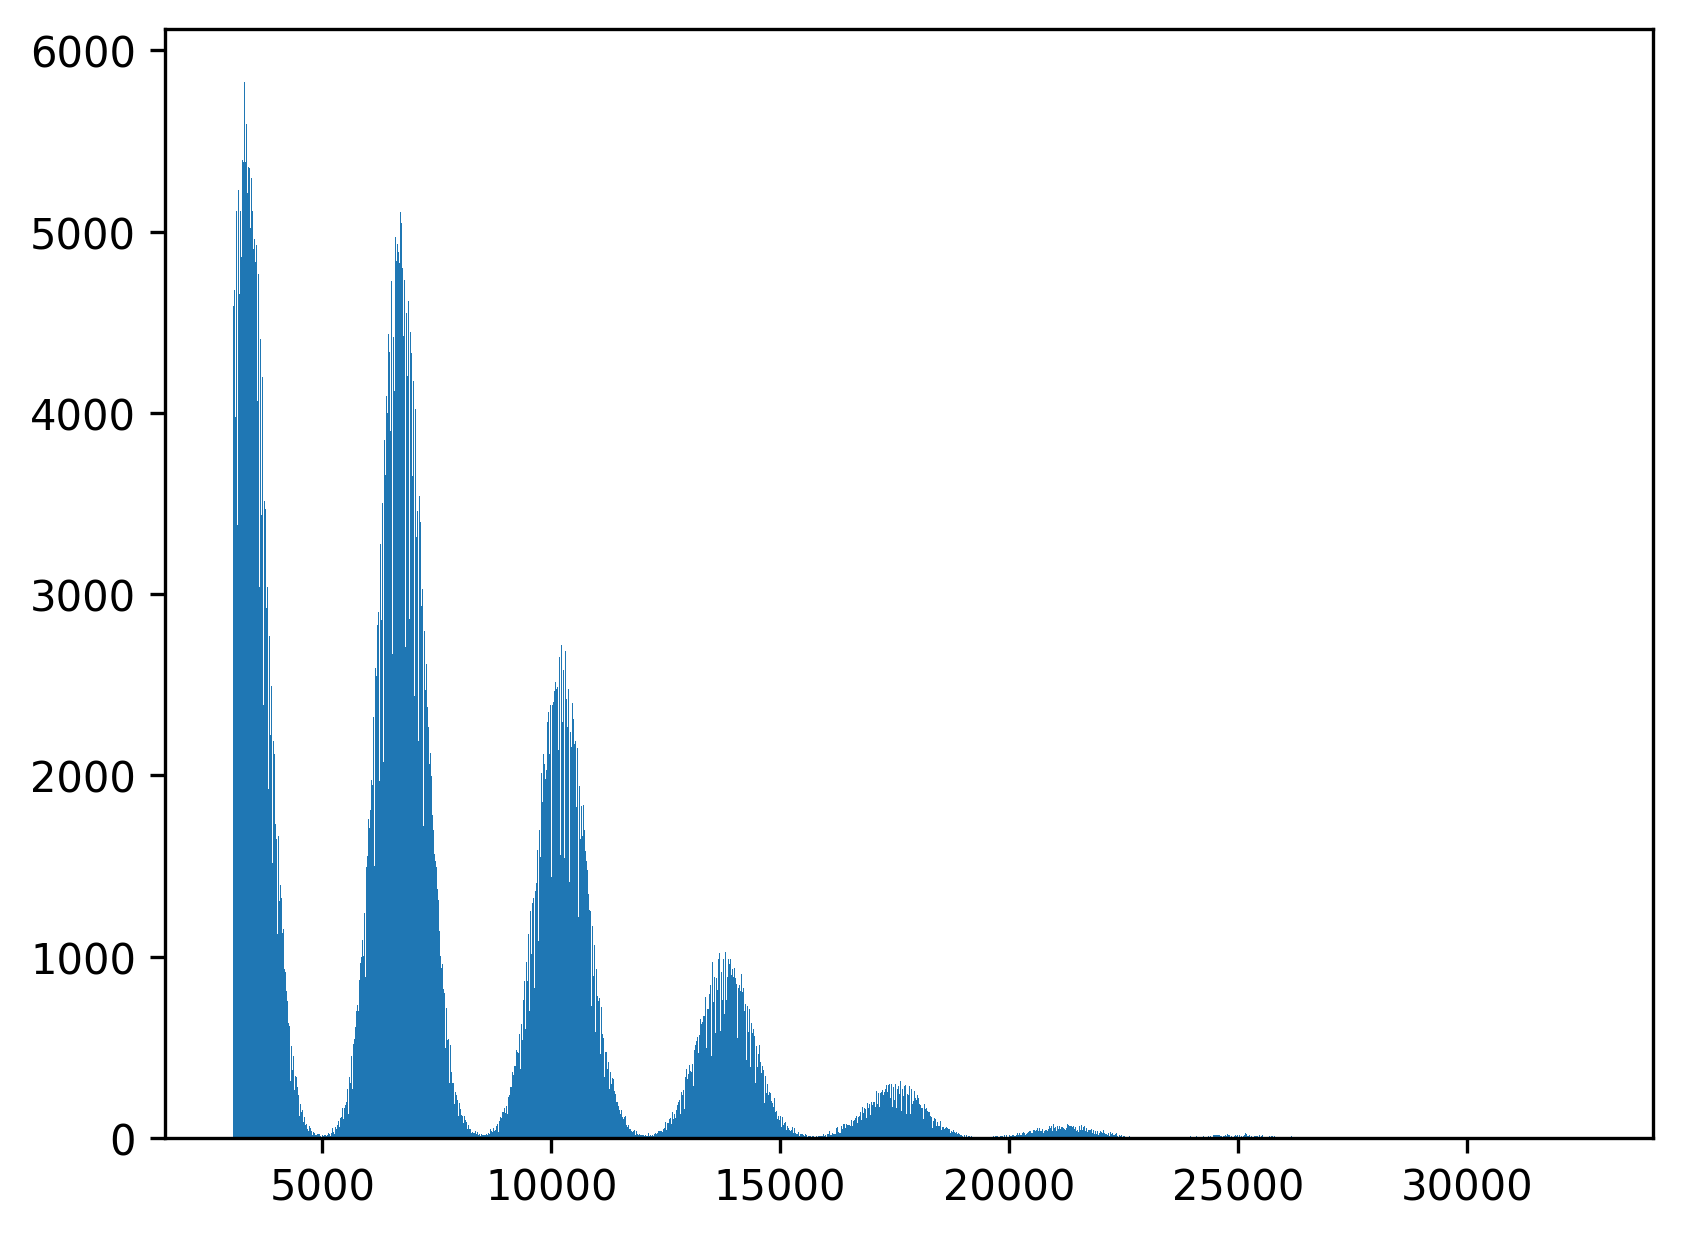

In [28]:
plt.figure(dpi=300)
plt.hist(max_amplitude_mu_3, bins=2000)
plt.savefig(os.path.join(save_dir, "max_amplitude_histogram_mu_3.png"), dpi=500)
plt.show()

In [ ]:
def valley_thresholds_from_hist_data(data, bins=2000, peak_prominence=100, peak_distance=20):
    """
    Build histogram from data, find peaks, then find the minimum point
    between each neighboring pair of peaks.

    Parameters
    ----------
    data : array-like
        Raw sample values.
    bins : int
        Number of histogram bins.
    peak_prominence : float
        Minimum prominence for peak finding.
    peak_distance : int
        Minimum distance between peaks in bin units.

    Returns
    -------
    counts : np.ndarray
        Histogram counts.
    bin_edges : np.ndarray
        Histogram bin edges.
    bin_centers : np.ndarray
        Histogram bin centers.
    peaks : np.ndarray
        Indices of detected peaks in the histogram.
    valley_indices : list
        Histogram indices of minima between peaks.
    valley_x : list
        x positions of those minima.
    """
    counts, bin_edges = np.histogram(data, bins=bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    peaks, _ = find_peaks(counts, prominence=peak_prominence, distance=peak_distance)

    valley_indices = []
    valley_x = []

    for i in range(len(peaks) - 1):
        left = peaks[i]
        right = peaks[i + 1]

        local_min_idx = np.argmin(counts[left:right+1]) + left
        valley_indices.append(local_min_idx)
        valley_x.append(bin_centers[local_min_idx])

    return counts, bin_edges, bin_centers, peaks, valley_indices, valley_x

In [51]:
counts, bin_edges, bin_centers, peaks, valley_indices, valley_x = valley_thresholds_from_hist_data(
    max_amplitude_mu_3,
    bins=2000,
    peak_prominence=200,
    peak_distance=80
)

print("Peak x positions:", bin_centers[peaks])
print("Valley x positions:", valley_x)

Peak x positions: [ 3302.615  6760.667 10218.719 13809.773 17622.497]
Valley x positions: [np.float64(4972.529), np.float64(8460.136999999999), np.float64(12036.413), np.float64(15716.135000000002)]


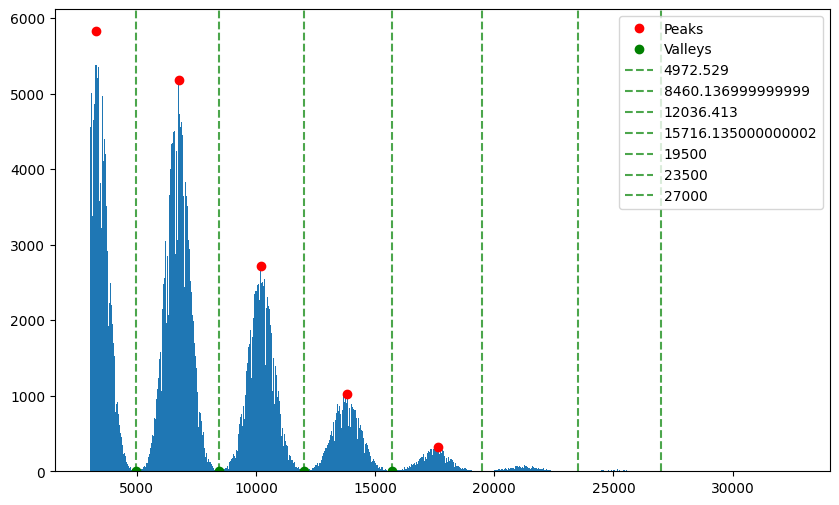

In [58]:

plt.figure(figsize=(10, 6))
plt.hist(max_amplitude_mu_3, bins=2000)

plt.plot(bin_centers[peaks], counts[peaks], "ro", label="Peaks")
plt.plot(bin_centers[valley_indices], counts[valley_indices], "go", label="Valleys")

for x in valley_x:
    plt.axvline(x=x, color="green", linestyle="--", alpha=0.7, label=x)
    
plt.axvline(x=19500, color="green", linestyle="--", alpha=0.7, label=19500)
plt.axvline(x=23500, color="green", linestyle="--", alpha=0.7, label=23500)
plt.axvline(x=27000, color="green", linestyle="--", alpha=0.7, label=27000)

plt.legend()
plt.savefig(os.path.join(save_dir, "max_amplitude_histogram_with_peaks_and_valleys_mu_3.png"), dpi=500)
plt.show()

In [65]:
maximum_amplitude_thresholds = [0, 4973, 8460, 12036, 15716, 19500, 23500, 27000]

In [67]:
photon_number_distribution_mu_3 = classify_photon_number_max_ampltitude(seperated_waveforms_mu_3, maximum_amplitude_thresholds)
photon_number_distribution_mu_2 = classify_photon_number_max_ampltitude(seperated_waveforms_mu_2, maximum_amplitude_thresholds)
photon_number_distribution_mu_1 = classify_photon_number_max_ampltitude(seperated_waveforms_mu_1, maximum_amplitude_thresholds)
photon_number_distribution_mu_05 = classify_photon_number_max_ampltitude(seperated_waveforms_mu_05, maximum_amplitude_thresholds)

In [83]:
len(photon_number_distribution_mu_3)
print(photon_number_distribution_mu_3[:10])

count = np.sum(np.array(photon_number_distribution_mu_3) == 0)
print(count)

[np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(4), np.int64(4), np.int64(1), np.int64(2), np.int64(2)]
0


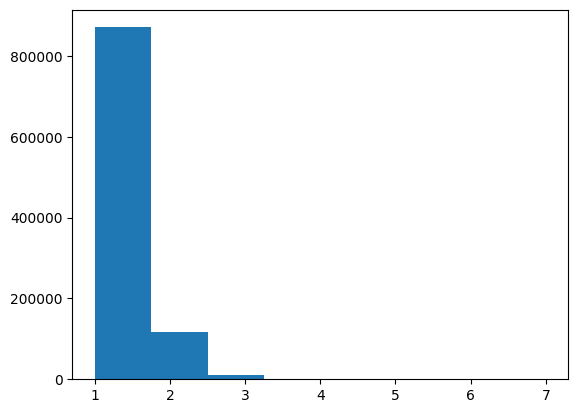

In [92]:
plt.hist(np.array(photon_number_distribution_mu_05), bins=8)
plt.show()

In [ ]:
measured_counts_from_data_mu_3 = count_photon_numbers(photon_number_distribution_mu_3)
measured_counts_from_data_mu_2 = count_photon_numbers(photon_number_distribution_mu_2)
measured_counts_from_data_mu_1 = count_photon_numbers(photon_number_distribution_mu_1)
measured_counts_from_data_mu_05 = count_photon_numbers(photon_number_distribution_mu_05)
print(np.sum(measured_counts_from_data_mu_3))
print(np.sum(measured_counts_from_data_mu_2))
print(np.sum(measured_counts_from_data_mu_1))
print(np.sum(measured_counts_from_data_mu_05))


1000000
1000000
1000000
1000000


In [94]:
print(measured_counts_from_data_mu_3)

[     0 285722 374644 215254  88493  27597   6707   1319    264]


In [95]:
def calculate_zero_photon_amount(measured_counts, N_detected):
    counts = measured_counts[1:]
    total_counts = np.sum(measured_counts)
    zero_photon_count = int((1 - N_detected) * total_counts / N_detected)
    counts = np.insert(counts, 0, zero_photon_count)
    return counts

In [96]:
measured_counts_from_data_mu_3_with_zero = calculate_zero_photon_amount(measured_counts_from_data_mu_3, N_detected_mu_3)
measured_counts_from_data_mu_2_with_zero = calculate_zero_photon_amount(measured_counts_from_data_mu_2, N_detected_mu_2)
measured_counts_from_data_mu_1_with_zero = calculate_zero_photon_amount(measured_counts_from_data_mu_1, N_detected_mu_1)
measured_counts_from_data_mu_05_with_zero = calculate_zero_photon_amount(measured_counts_from_data_mu_05, N_detected_mu_05)
print(np.sum(measured_counts_from_data_mu_3_with_zero))
print(np.sum(measured_counts_from_data_mu_2_with_zero))
print(np.sum(measured_counts_from_data_mu_1_with_zero))
print(np.sum(measured_counts_from_data_mu_05_with_zero))

1210560
1529062
2382745
4166897


In [97]:
print(measured_counts_from_data_mu_3_with_zero)
print(measured_counts_from_data_mu_2_with_zero)
print(measured_counts_from_data_mu_1_with_zero)
print(measured_counts_from_data_mu_05_with_zero)

[210560 285722 374644 215254  88493  27597   6707   1319    264]
[529062 550857 310125 106823  26397   4963    723    100     12]
[1382745  751483  206703   36683    4615     475      41]
[3166897  871279  117814   10215     651      39       0       2]


measured_counts_from_data_mu_X_with_zero are the different counts I got from the 1M data in ram using max_amplitude logic.

In [120]:
def return_fraction_counts(R_detected):
    N_det = []
    for i in (R_detected):
        fraction = i/np.sum(R_detected)
        N_det.append(fraction)
    return N_det

def compare_fractions(saving_dir, mu, N_detected_DDR, N_detected_threshold):
    N_detected_DDR = np.asarray(N_detected_DDR, dtype=float)
    N_detected_threshold = np.asarray(N_detected_threshold, dtype=float)

    # pad threshold array if needed
    if len(N_detected_threshold) < len(N_detected_DDR):
        N_detected_thresholds = np.pad(
            N_detected_threshold,
            (0, len(N_detected_DDR) - len(N_detected_threshold)),
            mode='constant'
        )
    else:
        N_detected_thresholds = N_detected_threshold[:len(N_detected_DDR)]

    differences = N_detected_DDR - N_detected_thresholds

    # percent difference relative to threshold fractions
    percent_differences = np.where(
        N_detected_thresholds != 0,
        100 * differences / N_detected_thresholds,
        np.nan
    )

    print("Differences between DDR and threshold fractions:", differences)
    print("Difference between detected-or-not-detected fractions:",
          np.sum(N_detected_DDR[1:]) - np.sum(N_detected_thresholds[1:]))

    os.makedirs(saving_dir, exist_ok=True)
    save_path = os.path.join(saving_dir, f"fraction_differences_mu_{mu}.txt")

    with open(save_path, "w", encoding="utf-8") as f:
        f.write(f"Comparison of photon fractions for mu = {mu}\n\n")

        for i in range(len(differences)):
            f.write(
                f"Difference {i} photon fraction = "
                f"{percent_differences[i]:.6f}% ; raw value = {differences[i]:.10f}\n"
            )

        f.write("\n")
        f.write(
            f"Difference between detected-or-not-detected fractions = "
            f"{(np.sum(N_detected_DDR[1:]) - np.sum(N_detected_thresholds[1:])):.10f}\n"
        )

    return differences, percent_differences

In [117]:
N_detected_mu_3_fractions = return_fraction_counts(individual_counts_mu_3)
N_detected_mu_2_fractions = return_fraction_counts(individual_counts_mu_2)
N_detected_mu_1_fractions = return_fraction_counts(individual_counts_mu_1)
N_detected_mu_05_fractions = return_fraction_counts(individual_counts_mu_05)

N_detected_mu_3_fractions_DDR = return_fraction_counts(measured_counts_from_data_mu_3_with_zero)
N_detected_mu_2_fractions_DDR = return_fraction_counts(measured_counts_from_data_mu_2_with_zero)
N_detected_mu_1_fractions_DDR = return_fraction_counts(measured_counts_from_data_mu_1_with_zero)
N_detected_mu_05_fractions_DDR = return_fraction_counts(measured_counts_from_data_mu_05_with_zero)

In [122]:
compare_fractions(save_dir, 3, N_detected_mu_3_fractions_DDR, N_detected_mu_3_fractions)
compare_fractions(save_dir, 2, N_detected_mu_2_fractions_DDR, N_detected_mu_2_fractions)
compare_fractions(save_dir, 1, N_detected_mu_1_fractions_DDR, N_detected_mu_1_fractions)
compare_fractions(save_dir, 0.5, N_detected_mu_05_fractions_DDR, N_detected_mu_05_fractions)


Differences between DDR and threshold fractions: [-6.44276191e-07 -7.97881397e-02  3.65223650e-02  2.59329713e-02
  1.21218582e-02 -5.13182306e-04  5.50431110e-03  2.37979031e-06
  2.18080888e-04]
Difference between detected-or-not-detected fractions: 6.442761911751305e-07
Differences between DDR and threshold fractions: [-1.67830256e-07 -1.38392946e-02  7.35587604e-03  4.61596936e-03
 -1.92425010e-03  3.24578075e-03  4.72838904e-04  6.53995718e-05
  7.84794861e-06]
Difference between detected-or-not-detected fractions: 1.6783025569289123e-07
Differences between DDR and threshold fractions: [-6.54905570e-08 -3.53707907e-03  2.29275576e-03  1.04818755e-03
 -2.03557038e-05  1.99349909e-04  1.72070448e-05]
Difference between detected-or-not-detected fractions: 6.549055697746553e-08
Differences between DDR and threshold fractions: [-4.55160647e-08 -4.35426404e-04  3.53933320e-04 -8.45322202e-05
  1.56231364e-04  9.35948261e-06  0.00000000e+00  4.79973467e-07]
Difference between detected-or

/var/folders/0y/496_zl5905jfg059dd524bvm0000gn/T/ipykernel_30984/1366964638.py:27: RuntimeWarning: divide by zero encountered in divide
  100 * differences / N_detected_thresholds,
/var/folders/0y/496_zl5905jfg059dd524bvm0000gn/T/ipykernel_30984/1366964638.py:27: RuntimeWarning: invalid value encountered in divide
  100 * differences / N_detected_thresholds,


(array([-4.55160647e-08, -4.35426404e-04,  3.53933320e-04, -8.45322202e-05,
         1.56231364e-04,  9.35948261e-06,  0.00000000e+00,  4.79973467e-07]),
 array([-5.98885098e-06, -2.07810187e-01,  1.26767567e+00, -3.33329377e+00,
                    nan,             nan,             nan,             nan]))

In [125]:

N_detected_mu_2_fractions = np.pad(N_detected_mu_2_fractions, (0, 8 - len(N_detected_mu_2_fractions)), mode='constant')
N_detected_mu_1_fractions = np.pad(N_detected_mu_1_fractions, (0, 8 - len(N_detected_mu_1_fractions)), mode='constant')
N_detected_mu_05_fractions = np.pad(N_detected_mu_05_fractions, (0, 8 - len(N_detected_mu_05_fractions)), mode='constant')

In [127]:
print(len(N_detected_mu_3_fractions))
print(len(N_detected_mu_2_fractions))
print(len(N_detected_mu_1_fractions))
print(len(N_detected_mu_05_fractions))
print(N_detected_mu_3_fractions)
print(N_detected_mu_2_fractions)
print(N_detected_mu_1_fractions)
print(N_detected_mu_05_fractions)

8
8
8
8
[np.float64(0.17393667388232395), np.float64(0.3158127894433737), np.float64(0.2729575451551913), np.float64(0.15188060255521668), np.float64(0.060979020727273056), np.float64(0.023310069696909394), np.float64(3.609995307006101e-05), np.float64(0.0010871985866418373)]
[0.34600445 0.37409741 0.19546455 0.06524582 0.01918778 0.
 0.         0.        ]
[0.58031605 0.31892249 0.08445719 0.01434708 0.0019572  0.
 0.         0.        ]
[0.76001331 0.20953083 0.02791986 0.002536   0.         0.
 0.         0.        ]


In [153]:
np.savetxt(os.path.join(save_dir, "N_detected_mu_3_fraction.csv"), N_detected_mu_3_fractions, delimiter=",")
np.savetxt(os.path.join(save_dir, "N_detected_mu_2_fraction.csv"), N_detected_mu_2_fractions, delimiter=",")
np.savetxt(os.path.join(save_dir, "N_detected_mu_1_fraction.csv"), N_detected_mu_1_fractions, delimiter=",")
np.savetxt(os.path.join(save_dir, "N_detected_mu_05_fraction.csv"), N_detected_mu_05_fractions, delimiter=",")

np.savetxt(os.path.join(save_dir, "Count_detected_mu_3_fraction.csv"), individual_counts_mu_3, delimiter=",")
np.savetxt(os.path.join(save_dir, "Count_detected_mu_2_fraction.csv"), individual_counts_mu_2, delimiter=",")
np.savetxt(os.path.join(save_dir, "Count_detected_mu_1_fraction.csv"), individual_counts_mu_1, delimiter=",")
np.savetxt(os.path.join(save_dir, "Count_detected_mu_05_fraction.csv"), individual_counts_mu_05, delimiter=",")

In [154]:
np.savetxt(os.path.join(save_dir, "N_detected_mu_3_fraction_DDR.csv"), N_detected_mu_3_fractions_DDR, delimiter=",")
np.savetxt(os.path.join(save_dir, "N_detected_mu_2_fraction_DDR.csv"), N_detected_mu_2_fractions_DDR, delimiter=",")
np.savetxt(os.path.join(save_dir, "N_detected_mu_1_fraction_DDR.csv"), N_detected_mu_1_fractions_DDR, delimiter=",")
np.savetxt(os.path.join(save_dir, "N_detected_mu_05_fraction_DDR.csv"), N_detected_mu_05_fractions_DDR, delimiter=",")

np.savetxt(os.path.join(save_dir, "Count_detected_mu_3_fraction_DDR.csv"), measured_counts_from_data_mu_3_with_zero, delimiter=",")
np.savetxt(os.path.join(save_dir, "Count_detected_mu_2_fraction_DDR.csv"), measured_counts_from_data_mu_2_with_zero, delimiter=",")
np.savetxt(os.path.join(save_dir, "Count_detected_mu_1_fraction_DDR.csv"), measured_counts_from_data_mu_1_with_zero, delimiter=",")
np.savetxt(os.path.join(save_dir, "Count_detected_mu_05_fraction_DDR.csv"), measured_counts_from_data_mu_05_with_zero, delimiter=",")


In [ ]:
# data_mu_3 = np.loadtxt(os.path.join(data_path_mu_3, "continuous_waveforms_1M.csv"), delimiter=",")


path = '/Volumes/RFsoc/ZCU208B/Data/20260312/Matterhorn/gN2a8-10/Pulsed_Laser_Source/1358/Signal_analysis/N_detected_mu_3_fraction.csv'

test = np.loadtxt(path, delimiter=",")

In [ ]:
print(test)

In [ ]:
type(test)

In [133]:

print(measured_mu_3)
print(measured_mu_2)
print(measured_mu_1)
print(measured_mu_05)

2.9960737977682093
1.989800885550521
0.9834312457408315
0.48887501804981454


In [141]:
print(N_detected_mu_3_fractions_DDR)
print(N_detected_mu_3_fractions)

[np.float64(0.1739360296061327), np.float64(0.23602464974887655), np.float64(0.30947991012424003), np.float64(0.17781357388316152), np.float64(0.0731008789320645), np.float64(0.022796887390959555), np.float64(0.005540411049431668), np.float64(0.001089578376949511), np.float64(0.00021808088818398098)]
[np.float64(0.17393667388232395), np.float64(0.3158127894433737), np.float64(0.2729575451551913), np.float64(0.15188060255521668), np.float64(0.060979020727273056), np.float64(0.023310069696909394), np.float64(3.609995307006101e-05), np.float64(0.0010871985866418373)]


In [142]:
def poisson_probs(mu, n_max):
    n = np.arange(0, n_max + 1)
    probs = np.array([np.exp(-mu) * mu**k / math.factorial(k) for k in n], dtype=float)
    return n, probs

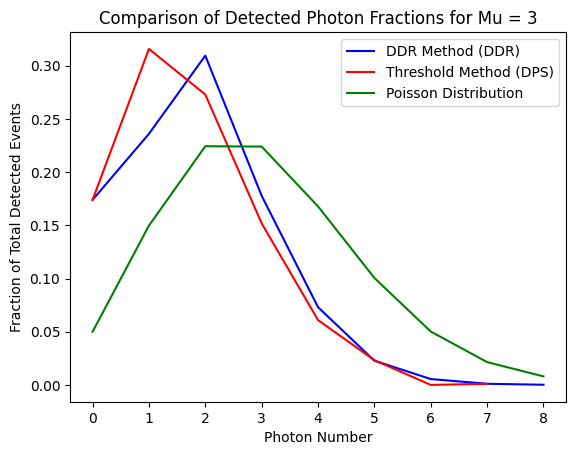

In [149]:
# plt.figure(dpi=300)

mu_3_poisson = poisson_probs(measured_mu_3, 8)

plt.plot(N_detected_mu_3_fractions_DDR, color='blue', label="DDR Method (DDR)")
plt.plot(N_detected_mu_3_fractions, color='red', label="Threshold Method (DPS)")
plt.plot(mu_3_poisson[0], mu_3_poisson[1], color='green', label="Poisson Distribution")
plt.xlabel("Photon Number")
plt.ylabel("Fraction of Total Detected Events")
plt.title(f"Comparison of Detected Photon Fractions for Mu = 3")
plt.legend()
plt.savefig(os.path.join(save_dir, "fraction_comparison_mu_3.png"), dpi=500)
plt.show()

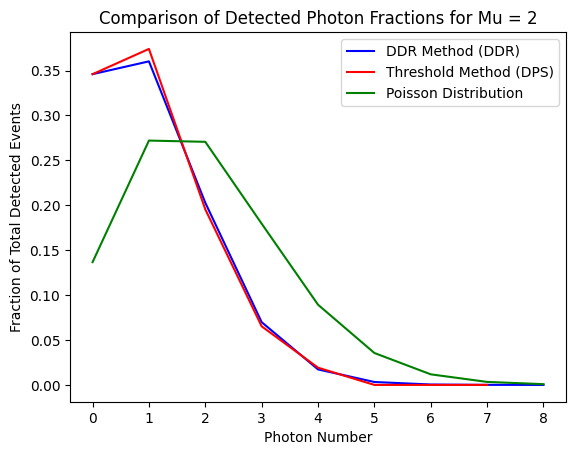

In [150]:
# plt.figure(dpi=300)

mu_2_poisson = poisson_probs(measured_mu_2, 8)

plt.plot(N_detected_mu_2_fractions_DDR, color='blue', label="DDR Method (DDR)")
plt.plot(N_detected_mu_2_fractions, color='red', label="Threshold Method (DPS)")
plt.plot(mu_2_poisson[0], mu_2_poisson[1], color='green', label="Poisson Distribution")
plt.xlabel("Photon Number")
plt.ylabel("Fraction of Total Detected Events")
plt.title(f"Comparison of Detected Photon Fractions for Mu = 2")
plt.legend()
plt.savefig(os.path.join(save_dir, "fraction_comparison_mu_2.png"), dpi=500)
plt.show()

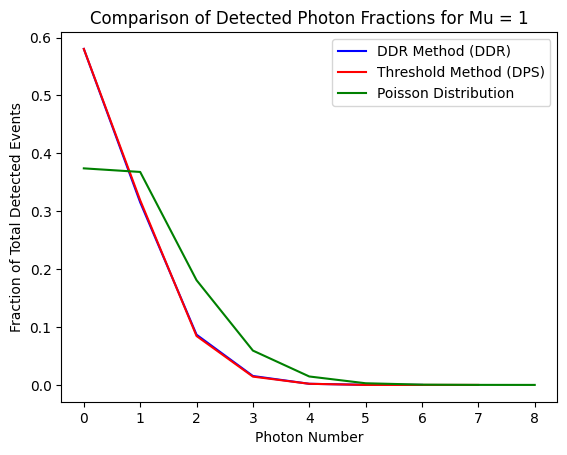

In [151]:
# plt.figure(dpi=300)

mu_1_poisson = poisson_probs(measured_mu_1, 8)

plt.plot(N_detected_mu_1_fractions_DDR, color='blue', label="DDR Method (DDR)")
plt.plot(N_detected_mu_1_fractions, color='red', label="Threshold Method (DPS)")
plt.plot(mu_1_poisson[0], mu_1_poisson[1], color='green', label="Poisson Distribution")
plt.xlabel("Photon Number")
plt.ylabel("Fraction of Total Detected Events")
plt.title(f"Comparison of Detected Photon Fractions for Mu = 1")
plt.legend()
plt.savefig(os.path.join(save_dir, "fraction_comparison_mu_1.png"), dpi=500)
plt.show()

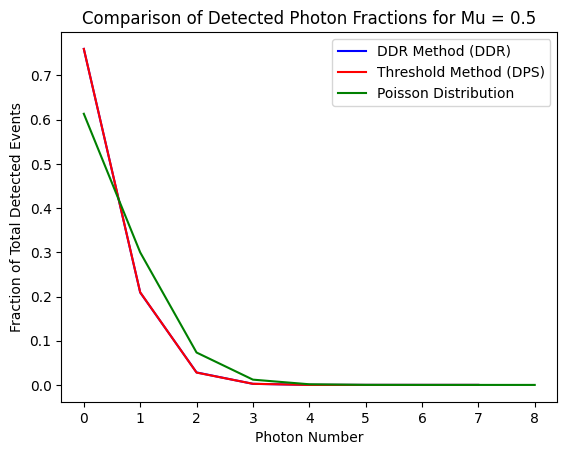

In [152]:
# plt.figure(dpi=300)

mu_05_poisson = poisson_probs(measured_mu_05, 8)

plt.plot(N_detected_mu_05_fractions_DDR, color='blue', label="DDR Method (DDR)")
plt.plot(N_detected_mu_05_fractions, color='red', label="Threshold Method (DPS)")
plt.plot(mu_05_poisson[0], mu_05_poisson[1], color='green', label="Poisson Distribution")
plt.xlabel("Photon Number")
plt.ylabel("Fraction of Total Detected Events")
plt.title(f"Comparison of Detected Photon Fractions for Mu = 0.5")
plt.legend()
plt.savefig(os.path.join(save_dir, "fraction_comparison_mu_05.png"), dpi=500)
plt.show()